# 27 — Single Case: IG vs SHAP Attribution — BPIC17

Enter a case name and prefix length to see side-by-side:
- Integrated Gradients attribution heatmap
- SHAP attribution heatmap
- Delta (IG - SHAP) heatmap

In [1]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(
    model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories)

case_names = list(eval_helper.cases.keys())
print(f'Cases: {len(case_names)}')
print(f'Sample: {case_names[:5]}')

/Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/attribution/shap_explainer.py:21: SyntaxWarning: invalid escape sequence '\{'
  """


Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

In [3]:
# ============================================
# CONFIGURATION — change these
# ============================================
CASE_NAME = "Application_1001866944"
PREFIX_LENGTH = 1
IG_STEPS = 30
SHAP_SAMPLES = 30
TARGET = CONFIG.concept_name

In [4]:
# Get prefix
case = eval_helper.cases[CASE_NAME]
for pl, prefix, suffix in eval_helper._iterate_case(case):
    if pl == PREFIX_LENGTH:
        break

cat_t = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
num_t = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
process = (cat_t, num_t)

# Compute IG
attr_ig = tool.compute_attribution_map(
    process=process, prefix_length=PREFIX_LENGTH,
    target=TARGET, target_class='auto',
    method='integrated_gradients', n_steps=IG_STEPS)

# Compute SHAP
attr_shap = tool.compute_attribution_map(
    process=process, prefix_length=PREFIX_LENGTH,
    target=TARGET, target_class='auto',
    method='shap', n_samples=SHAP_SAMPLES)

print(f'Case: {CASE_NAME}, Prefix: {PREFIX_LENGTH}')
print(f'IG target:   {attr_ig.target_description}')
print(f'SHAP target: {attr_shap.target_description}')

Case: Application_1001866944, Prefix: 1
IG target:   concept:name = W_Handle leads (class 24) [integrated_gradients]
SHAP target: concept:name = W_Handle leads (class 24) [shap]


## Side-by-side heatmaps: IG, SHAP, Delta

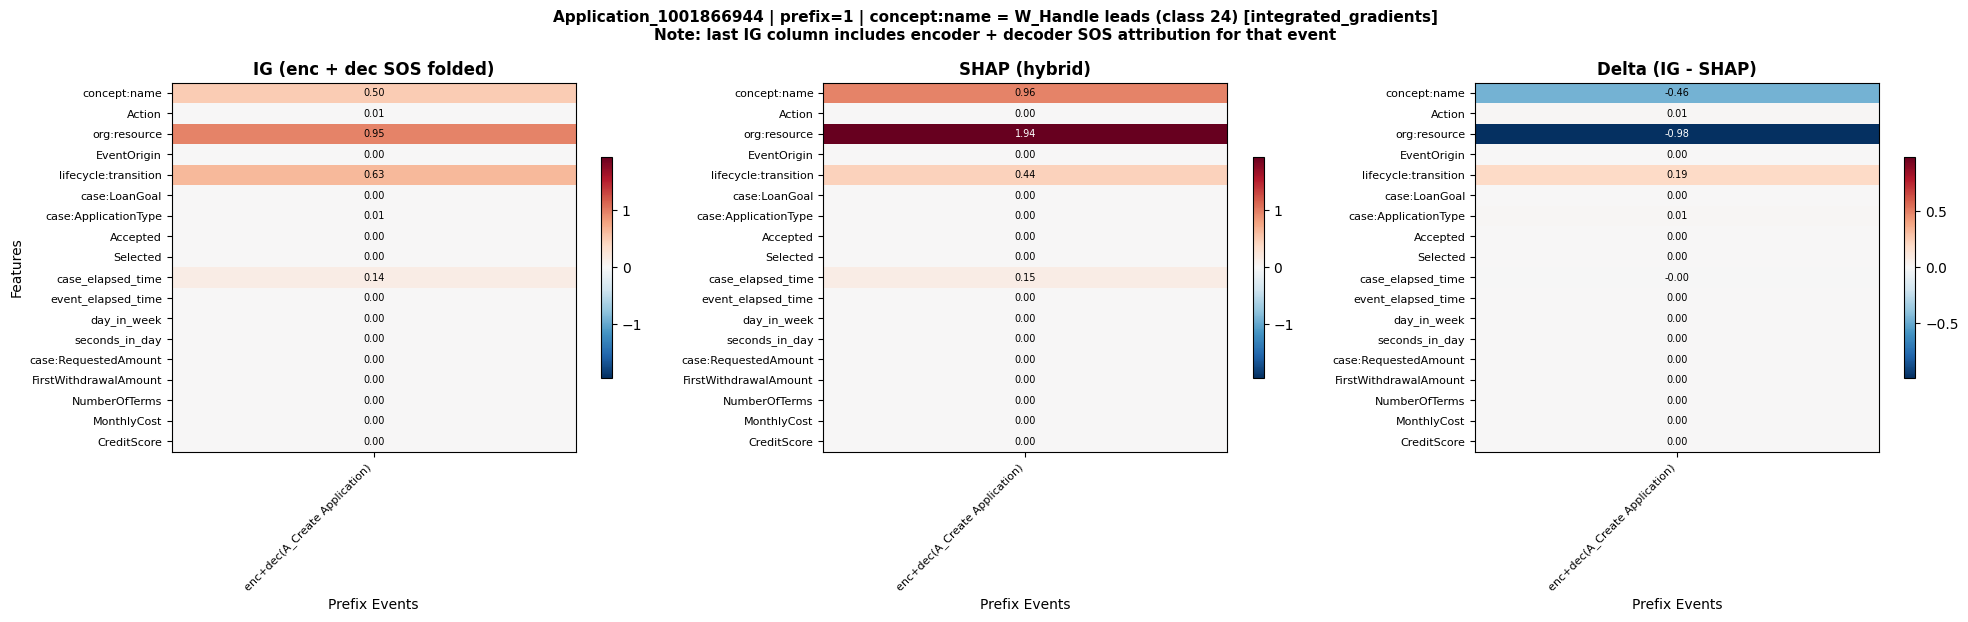

In [5]:
def to_matrix(attr_map, fold_dec_sos=False):
    """Build (features x steps) matrix from AttributionMap.
    If fold_dec_sos=True, add the dec(SOS) column into the last encoder column."""
    n_f = len(attr_map.feature_names)
    n_s = len(attr_map.step_labels)
    mat = np.zeros((n_f, n_s))
    for i, feat in enumerate(attr_map.feature_names):
        if feat in attr_map.attributions:
            vals = attr_map.attributions[feat]
            if hasattr(vals, 'detach'):
                vals = vals.detach().cpu().numpy()
            vals = np.asarray(vals).flatten()
            mat[i, :min(len(vals), n_s)] = vals[:n_s]

    if fold_dec_sos:
        # Find the dec(SOS) column and fold it into the last encoder column
        sos_idx = None
        last_enc_idx = None
        for j, label in enumerate(attr_map.step_labels):
            if label.startswith('dec(SOS'):
                sos_idx = j
            elif label.startswith('enc('):
                last_enc_idx = j
        if sos_idx is not None and last_enc_idx is not None:
            mat[:, last_enc_idx] += mat[:, sos_idx]
            # Remove the SOS column
            keep = [j for j in range(n_s) if j != sos_idx]
            mat = mat[:, keep]
            labels = [attr_map.step_labels[j] for j in keep]
            # Rename last enc label to show it includes SOS
            labels[last_enc_idx] = labels[last_enc_idx].replace('enc(', 'enc+dec(')
            return mat, labels
    return mat, list(attr_map.step_labels)

# IG: fold dec(SOS) into last encoder step
mat_ig, labels_ig = to_matrix(attr_ig, fold_dec_sos=True)
# SHAP: no decoder positions to fold
mat_shap, labels_shap = to_matrix(attr_shap, fold_dec_sos=False)

# Ensure same number of steps (SHAP has only encoder positions)
min_steps = min(mat_ig.shape[1], mat_shap.shape[1])
mat_ig = mat_ig[:, :min_steps]
mat_shap = mat_shap[:, :min_steps]
mat_delta = mat_ig - mat_shap
step_labels = labels_ig[:min_steps]

features = attr_ig.feature_names

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, max(5, len(features) * 0.35)))

vmax_abs = max(np.abs(mat_ig).max(), np.abs(mat_shap).max())
if vmax_abs == 0:
    vmax_abs = 1

for ax, mat, title in zip(axes, [mat_ig, mat_shap, mat_delta],
                           ['IG (enc + dec SOS folded)', 'SHAP (hybrid)', 'Delta (IG - SHAP)']):
    if title.startswith('Delta'):
        vmax_d = max(np.abs(mat_delta).max(), 1e-6)
        norm = TwoSlopeNorm(vmin=-vmax_d, vcenter=0, vmax=vmax_d)
    else:
        norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0, vmax=vmax_abs)

    im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', norm=norm, interpolation='nearest')
    ax.set_xticks(range(len(step_labels)))
    ax.set_xticklabels(step_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prefix Events')
    fig.colorbar(im, ax=ax, shrink=0.6)

    if mat.shape[0] * mat.shape[1] <= 80:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat[i, j]
                color = 'white' if abs(v) > vmax_abs * 0.5 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)

axes[0].set_ylabel('Features')
fig.suptitle(f'{CASE_NAME} | prefix={PREFIX_LENGTH} | {attr_ig.target_description}\n'
             f'Note: last IG column includes encoder + decoder SOS attribution for that event',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature-level summary

In [6]:
ig_totals = np.abs(mat_ig).sum(axis=1)
shap_totals = np.abs(mat_shap).sum(axis=1)
delta_totals = ig_totals - shap_totals

order = np.argsort(np.maximum(ig_totals, shap_totals))[::-1]

print(f'{"Feature":30s} {"IG (enc+dec)":>12s} {"SHAP":>8s} {"Delta":>8s}')
print('-' * 62)
for idx in order:
    print(f'{features[idx]:30s} {ig_totals[idx]:12.4f} {shap_totals[idx]:8.4f} {delta_totals[idx]:+8.4f}')

from scipy.stats import spearmanr
rho, p = spearmanr(ig_totals, shap_totals)
print(f'\nSpearman correlation (feature-level): {rho:.3f} (p={p:.4f})')

Feature                        IG (enc+dec)     SHAP    Delta
--------------------------------------------------------------
org:resource                         0.9538   1.9373  -0.9834
concept:name                         0.4966   0.9610  -0.4644
lifecycle:transition                 0.6348   0.4414  +0.1934
case_elapsed_time                    0.1430   0.1469  -0.0039
Action                               0.0143   0.0014  +0.0129
case:ApplicationType                 0.0117   0.0017  +0.0100
Selected                             0.0040   0.0000  +0.0040
case:LoanGoal                        0.0027   0.0003  +0.0024
Accepted                             0.0021   0.0000  +0.0021
EventOrigin                          0.0011   0.0003  +0.0008
day_in_week                          0.0005   0.0000  +0.0005
case:RequestedAmount                 0.0004   0.0001  +0.0004
seconds_in_day                       0.0001   0.0001  +0.0001
event_elapsed_time                   0.0000   0.0000  +0.0000
Monthly